In [5]:
from env3 import (
    make_simglucose_spid_env,
    #MultiPatientSimglucoseEnv,
    #parse_meal_schedule,
    #DEFAULT_MEALS
)

from simglucose.controller.basal_bolus_ctrller import BBController
from BBControllerWrapper import BBPolicy

In [6]:
env = make_simglucose_spid_env(scenario_mode="semi_random_hb", normalize=False)

In [ ]:
controller = BBController()

In [7]:
import pandas as pd
from datetime import timedelta
policy = BBPolicy(env)
obs, info = env.reset()


days = 0

full_history = []

while days <= 1:
    action, _ = policy.predict(obs)

    # Needs sample_time, 
    obs, reward, terminated, truncated, info = env.step(action)

    # print(obs)

    if terminated:
        hist = env.env.env.env.env.env.env.show_history().copy()
        hist.index = hist.index + timedelta(days=1)
        full_history.append(hist)

        obs, info = env.reset()
        days += 1
        break

full_history = pd.concat(full_history)

Observation(CGM=np.float32(138.0191))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(138.08487))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(138.54134))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(139.72134))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(141.44978))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(143.51733))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(145.69489))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(147.74152))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(149.40913))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(150.47093))
meal : 0.0
ctrller_action(basal=0.0

c:\GitHub\GGSpeciale\simglucose_singlepatient\env3.py:104: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([self.history, new_history], ignore_index=True)


In [18]:
insulin = [float(i) for i in full_history.insulin]

insulin = full_history.reset_index().insulin.astype("float")
insulin.index = full_history.reset_index()["Time"]

C:\Users\sofie\AppData\Local\Temp\ipykernel_34384\186885004.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  insulin = [float(i) for i in full_history.insulin]


In [21]:
insulin.resample("d").sum()

Time
2018-01-02    9.801667
Freq: D, Name: insulin, dtype: float64

In [ ]:
full_history.reset_index().re

,Time,BG,CGM,CHO,insulin,LBGI,HBGI,Risk
0,2018-01-02 00:00:00,150.291945,139.916287,0.0,[0.09801666666666667],0.000000,2.924912,2.924912
1,2018-01-02 00:03:00,150.845411,138.084874,0.0,[0.09801666666666667],0.000000,2.999855,2.999855
2,2018-01-02 00:06:00,151.453482,138.541331,0.0,[0.09801666666666667],0.000000,3.082969,3.082969
3,2018-01-02 00:09:00,151.866433,139.721342,0.0,[0.09801666666666667],0.000000,3.139870,3.139870
4,2018-01-02 00:12:00,152.153718,141.449780,0.0,[0.09801666666666667],0.000000,3.179672,3.179672
...,...,...,...,...,...,...,...,...
96,2018-01-02 04:48:00,61.251468,41.892979,0.0,[0.09801666666666667],12.699246,0.000000,12.699246
97,2018-01-02 04:51:00,60.318571,40.770307,0.0,[0.09801666666666667],13.344358,0.000000,13.344358
98,2018-01-02 04:54:00,59.402811,41.054205,0.0,[0.09801666666666667],14.003094,0.000000,14.003094
99,2018-01-02 04:57:00,58.503912,40.972785,0.0,[0.09801666666666667],14.675230,0.000000,14.675230


In [ ]:
insulin = [float(I) for I in full_history["insulin"]]
full_history["insulin2"] = insulin

C:\Users\sofie\AppData\Local\Temp\ipykernel_41828\247937173.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  insulin = [float(I) for I in full_history["insulin"]]


In [ ]:
full_history

,BG,CGM,CHO,insulin,LBGI,HBGI,Risk,insulin2
Time,,,,,,,,
2018-01-02 00:00:00,151.274760,145.816560,0.0,[0.09801666666666667],0.000000,3.058457,3.058457,0.098017
2018-01-02 00:03:00,152.234156,147.283208,0.0,[0.09801666666666667],0.000000,3.190848,3.190848,0.098017
2018-01-02 00:06:00,153.262710,149.321348,0.0,[0.09801666666666667],0.000000,3.334959,3.334959,0.098017
2018-01-02 00:09:00,153.935553,151.025938,0.0,[0.09801666666666667],0.000000,3.430427,3.430427,0.098017
2018-01-02 00:12:00,154.383646,152.580790,0.0,[0.09801666666666667],0.000000,3.494523,3.494523,0.098017
...,...,...,...,...,...,...,...,...
2018-01-02 06:36:00,17.172926,39.000000,0.0,[0.09801666666666667],118.039935,0.000000,118.039935,0.098017
2018-01-02 06:39:00,15.263972,39.000000,0.0,[0.09801666666666667],132.915881,0.000000,132.915881,0.098017
2018-01-02 06:42:00,13.336974,39.000000,0.0,[0.09801666666666667],150.963899,0.000000,150.963899,0.098017


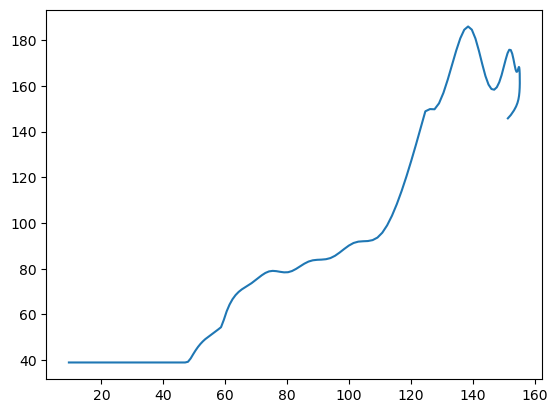

In [ ]:
plt.plot(full_history["BG"], full_history["CGM"])

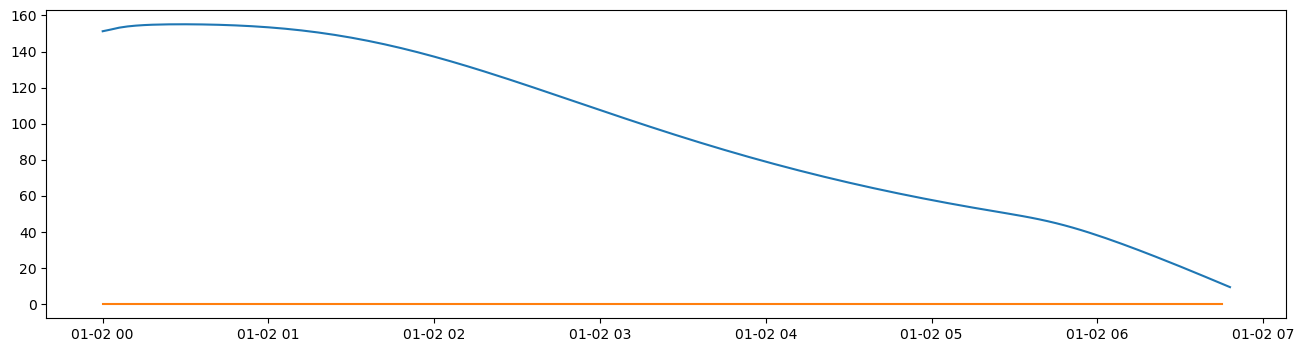

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.plot(full_history.index, full_history["BG"])
plt.plot(full_history.index, full_history["CHO"])

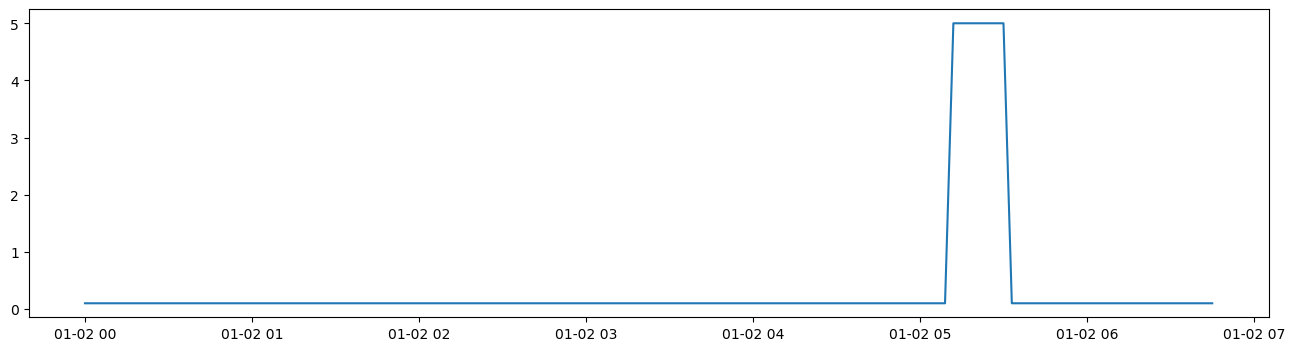

In [ ]:
plt.figure(figsize=(16, 4))
plt.plot(full_history.index, full_history["insulin2"])

Observation(CGM=np.float64(157.3231568938086))
Observation(CGM=np.float64(157.310988694269))
Observation(CGM=np.float64(157.08212506758503))
Observation(CGM=np.float64(156.29854142349257))
Observation(CGM=np.float64(154.99163965504385))
Observation(CGM=np.float64(153.08422180470208))
Observation(CGM=np.float64(150.42042871219047))
Observation(CGM=np.float64(146.8704464334352))
Observation(CGM=np.float64(142.4236279302522))
Observation(CGM=np.float64(137.1894648692957))
Observation(CGM=np.float64(131.24244390724897))
Observation(CGM=np.float64(124.48924455010041))
Observation(CGM=np.float64(116.789797110928))
Observation(CGM=np.float64(108.0545541030809))
Observation(CGM=np.float64(98.38460290363167))
Observation(CGM=np.float64(88.18138376241308))
Observation(CGM=np.float64(78.16855520874122))
Observation(CGM=np.float64(69.08179809660821))
Observation(CGM=np.float64(61.59605433082241))
Observation(CGM=np.float64(56.25475900436811))
Observation(CGM=np.float64(53.04436489443367))
Observat

KeyboardInterrupt: 

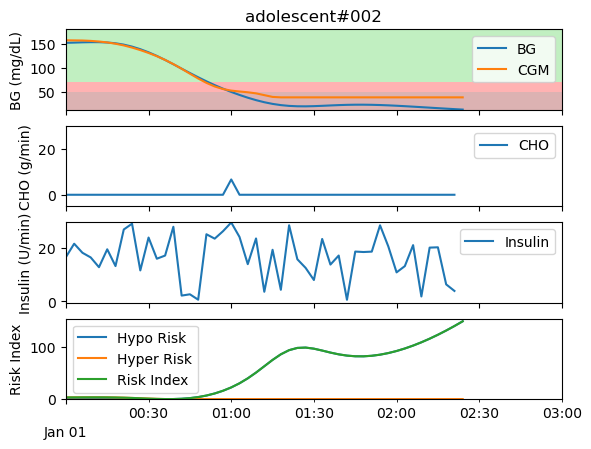

In [ ]:
import gym
from gym.envs.registration import register
from simglucose.simulation.scenario import CustomScenario
from datetime import datetime

start_time = datetime(2018, 1, 1, 0, 0, 0)
meal_scenario = CustomScenario(start_time=start_time, scenario=[(1,20)])


# register(
#     id='simglucose-adolescent2-v1',
#     entry_point='simglucose.envs:T1DSimEnv',
#     kwargs={'patient_name': 'adolescent#002',
#             'custom_scenario': meal_scenario}
# )

observation = env.reset()
for t in range(100):
    env.render(mode='human')
    print(observation)
    # Action in the gym environment is a scalar
    # representing the basal insulin, which differs from
    # the regular controller action outside the gym
    # environment (a tuple (basal, bolus)).
    # In the perfect situation, the agent should be able
    # to control the glucose only through basal instead
    # of asking patient to take bolus
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    if done:
        print("Episode finished after {} timesteps".format(t + 1))
        break

env = gym.make('simglucose-adolescent2-v1')

In [101]:
from simglucose.simulation.env import T1DSimEnv
from simglucose.controller.basal_bolus_ctrller import BBController
from simglucose.controller.pid_ctrller import PIDController

from simglucose.sensor.cgm import CGMSensor
from simglucose.actuator.pump import InsulinPump
from simglucose.patient.t1dpatient import T1DPatient
from simglucose.simulation.scenario_gen import RandomScenario
from simglucose.simulation.scenario import CustomScenario
from simglucose.simulation.sim_engine import SimObj, sim, batch_sim
from datetime import timedelta
from datetime import datetime

# specify start_time as the beginning of today
now = datetime.now()
start_time = datetime.combine(now.date(), datetime.min.time())

# --------- Create Random Scenario --------------
# Specify results saving path
path = './results'

# Create a simulation environment
patient = T1DPatient.withName('adult#001')
sensor = CGMSensor.withName('Dexcom')
pump = InsulinPump.withName('Insulet')
scenario = RandomScenario(start_time=start_time)
env = T1DSimEnv(patient, sensor, pump, scenario)

# Create a controller

#controller = PIDController(I=1, D=1)

# Put them together to create a simulation object

patient_list = ['adult#001'] #, 'adult#002', 'adult#003', 'adult#004', 'adult#005', 'adult#006', 'adult#007']


result_list = []
# for p_name in patient_list
for i in range(100):
    patient = T1DPatient.withName('adult#001')
    sensor = CGMSensor.withName('Dexcom')
    pump = InsulinPump.withName('Insulet')
    controller = BBController()



    scenario = RandomScenario(start_time=start_time)
    env = T1DSimEnv(patient, sensor, pump, scenario)

    s1 = SimObj(env, controller, timedelta(hours=3), animate=False, path=path)
    results1 = sim(s1)
    s1.reset()
    env.reset()

    result_list.append(results1)
print(results1)

Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process ID: 41144
Simulation starts ...
Simulation Completed!
Process 

In [98]:
controller.integrated_state

0

Index(['BG', 'CGM', 'CHO', 'insulin', 'LBGI', 'HBGI', 'Risk'], dtype='object')


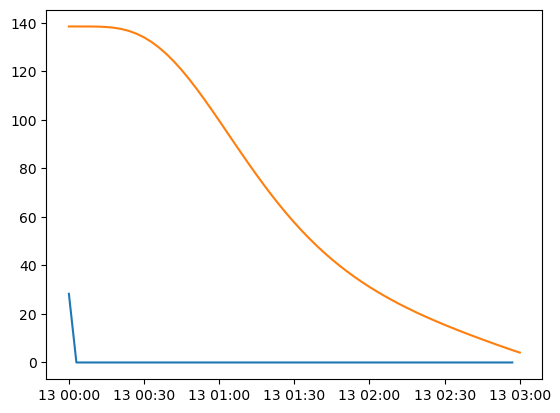

In [99]:
print(results1.columns)
plt.plot(results1["insulin"])
plt.plot(results1["BG"])

C:\Users\sofie\AppData\Local\Temp\ipykernel_41144\4294361094.py:6: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  df = pd.concat(


<Figure size 1200x600 with 0 Axes>

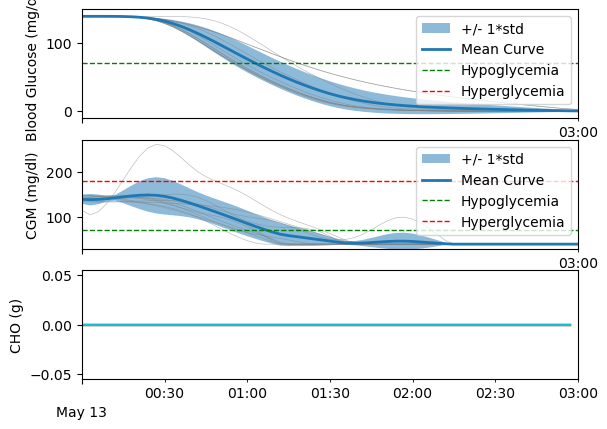

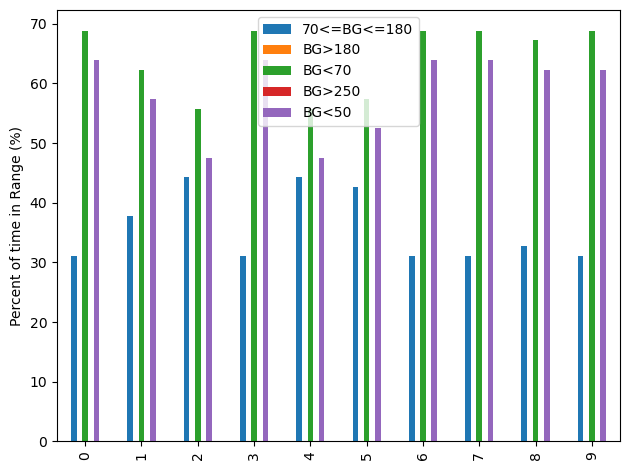

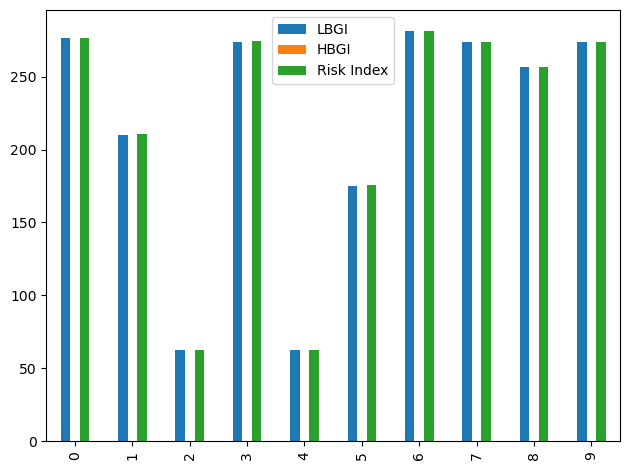

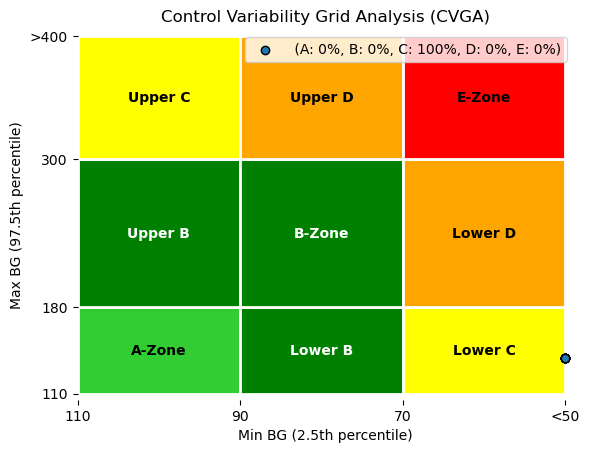

(   70<=BG<=180  BG>180      BG<70  BG>250      BG<50        LBGI      HBGI  \
 0    31.147541     0.0  68.852459     0.0  63.934426  276.323413  0.253802   
 1    37.704918     0.0  62.295082     0.0  57.377049  210.106116  0.291176   
 2    44.262295     0.0  55.737705     0.0  47.540984   62.445817  0.298638   
 3    31.147541     0.0  68.852459     0.0  63.934426  273.884972  0.245112   
 4    44.262295     0.0  55.737705     0.0  47.540984   62.445817  0.298638   
 5    42.622951     0.0  57.377049     0.0  52.459016  175.242860  0.421951   
 6    31.147541     0.0  68.852459     0.0  63.934426  281.264044  0.247181   
 7    31.147541     0.0  68.852459     0.0  63.934426  273.594124  0.245397   
 8    32.786885     0.0  67.213115     0.0  62.295082  256.435763  0.264294   
 9    31.147541     0.0  68.852459     0.0  62.295082  273.636449  0.253951   
 
    Risk Index  
 0  276.577215  
 1  210.397292  
 2   62.744455  
 3  274.130084  
 4   62.744455  
 5  175.664811  
 6  281.51

In [100]:
from simglucose.analysis.report import report
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

df = pd.concat(
        result_list,
        keys=range(10))

plt.figure(figsize=(12, 6))
report(df)

In [1]:
from train3 import make_env_fn
from evaluate import EvalInsulinPolicy
import argparse
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, VecMonitor


patient="adult#010"
meals = "7:45,12:70,16:15,18:80,23:10"

meals = [
    (7 * 60, 45.0),
    (12 * 60, 70.0),
    (16 * 60, 15.0),
    (18 * 60, 80.0),
    (23 * 60, 10.0),
]

eval_env = DummyVecEnv([
    make_env_fn(
        env_id="simglucose-spid-eval-v0",
        patient=patient,
        meals=meals,
        max_episode_steps=480,
        seed=None,
        scenario_mode="fixed",
        time_std_multiplier=1,
        include_snacks=True,
        reward_type="smooth",
        warning_window_min=20,
        insulin_tau_min=55,
        sample_time_min=3,
        max_insulin_action=5
    )
])

eval_env = VecMonitor(eval_env)
model = PPO.load(r"C:\GitHub\GGSpeciale\simglucose_singlepatient\teacher_models\smooth\adult-001\models\best\best_model.zip", env=eval_env)


c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\gym\envs\registration.py:2: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
c:\Users\sofie\anaconda3\envs\thesis-1\lib\site-packages\torch\cuda\__init__.py:184: UserWarning: cudaGetDeviceCount() returned cudaErrorNotSupported, likely using older driver or on CPU machine (Triggered internally at C:\bld\libtorch_1770197068560\work\c10\cuda\CUDAFunctions.cpp:88.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
evalCallback = EvalInsulinPolicy(eval_env, eval_freq=10, n_eval_episodes=5, deterministic=False)

model.learn(
    total_timesteps=20,
    callback=[
        evalCallback,
    ],
    progress_bar=False,
    tb_log_name="ppo_simglucose",
)

Logging to teacher_models/smooth/adult-001/logs\ppo_simglucose_43


c:\GitHub\GGSpeciale\simglucose_singlepatient\env3.py:104: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  pd.concat([self.history, new_history], ignore_index=True)


Eval num_timesteps=10, episode_reward=-1114.95 +/- 71.09
Episode length: 50.60 +/- 3.67
----------------------------------
| eval/              |           |
|    mean_ep_length  | 50.6      |
|    mean_reward     | -1.11e+03 |
| time/              |           |
|    total_timesteps | 10        |
----------------------------------
New best mean reward!
                               BG                           CGM              \
                              max         min count         max         min   
eval_index D                                                                  
1          2018-01-01  159.865136  154.585514    10  184.204397  160.787969   
2          2018-01-01  159.865136   29.954488    50  184.775307   40.336333   
3          2018-01-01  159.865136   31.654552    51  184.209262   40.325634   
4          2018-01-01  159.865136   24.393359    44  184.095381   40.409760   
5          2018-01-01  159.865136   36.877826    54  184.721346   42.112549   
6          20

c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["insulin2"] =  df.insulin.astype("float")
c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["D"] = df["Time"].dt.date


Eval num_timesteps=20, episode_reward=-1072.75 +/- 32.99
Episode length: 52.00 +/- 3.90
----------------------------------
| eval/              |           |
|    mean_ep_length  | 52        |
|    mean_reward     | -1.07e+03 |
| time/              |           |
|    total_timesteps | 20        |
----------------------------------
New best mean reward!
                               BG                           CGM              \
                              max         min count         max         min   
eval_index D                                                                  
0          2018-01-01  159.865136  155.740053    10  184.830158  160.787969   
1          2018-01-01  159.865136   40.688242    59  184.820506   42.592229   
2          2018-01-01  159.865136   28.769218    49  184.666998   41.633027   
3          2018-01-01  159.865136   33.211533    51  184.864210   41.513558   
4          2018-01-01  159.865136   35.637184    53  184.595857   41.816774   
5          20

...

Eval num_timesteps=130, episode_reward=-1070.21 +/- 48.33
Episode length: 50.20 +/- 2.14
----------------------------------
| eval/              |           |
|    mean_ep_length  | 50.2      |
|    mean_reward     | -1.07e+03 |
| time/              |           |
|    total_timesteps | 130       |
----------------------------------
                               BG                           CGM              \
                              max         min count         max         min   
eval_index D                                                                  
0          2018-01-01  159.865136  155.321110    10  184.608528  160.787969   
1          2018-01-01  159.865136   32.122784    49  184.197668   44.419500   
2          2018-01-01  159.865136   35.376388    53  184.181643   41.467320   
3          2018-01-01  159.865136   33.070730    50  184.528491   42.469714   
4          2018-01-01  159.865136   24.938022    47  184.417960   41.414822   
5          2018-01-01  159.865136 

c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["insulin2"] =  df.insulin.astype("float")
c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["D"] = df["Time"].dt.date


Eval num_timesteps=140, episode_reward=-1105.96 +/- 69.28
Episode length: 51.40 +/- 3.26
----------------------------------
| eval/              |           |
|    mean_ep_length  | 51.4      |
|    mean_reward     | -1.11e+03 |
| time/              |           |
|    total_timesteps | 140       |
----------------------------------
                               BG                           CGM              \
                              max         min count         max         min   
eval_index D                                                                  
0          2018-01-01  159.865136  155.269168    10  184.597707  160.787969   
1          2018-01-01  159.865136   23.199960    45  184.592102   40.303092   
2          2018-01-01  159.865136   35.060950    53  184.832298   41.388110   
3          2018-01-01  159.865136   33.881045    52  184.674945   41.090385   
4          2018-01-01  159.865136   34.448411    54  184.806359   40.348594   
5          2018-01-01  159.865136 

c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:154: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["insulin2"] =  df.insulin.astype("float")
c:\GitHub\GGSpeciale\simglucose_singlepatient\evaluate.py:155: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["D"] = df["Time"].dt.date


KeyboardInterrupt: 